In [7]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Constants
T = 298.15
kB = 8.617e-5
h = 4.135667e-15
kT = kB * T
log_prefactor = np.log(kT / h)

# 1. Generate Fake Data
P_vals = [0.001, 0.01, 0.1, 1.0]
C_vals = [0.1, 0.25, 0.5, 1.0]
P_grid, C_grid = np.meshgrid(P_vals, C_vals)
P_grid, C_grid = P_grid.ravel(), C_grid.ravel()

# Precompute logs for speed
log_P = np.log(P_grid)
log_C = np.log(C_grid)

dG1_true, dG2_true, dGact_true = -0.1, -0.04, 0.8

K1_true = np.exp(-dG1_true / kT)
K2_true = np.exp(-dG2_true / kT)
k_true = np.exp(log_prefactor - dGact_true / kT)

denom_true = 1 + K1_true * P_grid + K2_true * C_grid

theta_CO_exp = (K1_true * P_grid) / denom_true + np.random.normal(0, 0.02, len(P_grid))
theta_OH_exp = (K2_true * C_grid) / denom_true + np.random.normal(0, 0.02, len(P_grid))
log_rate_exp = np.log((k_true * C_grid * K1_true * P_grid) / denom_true) + np.random.normal(0, 0.1, len(P_grid))

# 2. Fit 1: Thetas
with pm.Model() as model_thetas:
    dG1 = pm.Uniform('dG1', lower=-2, upper=0.1)
    dG2 = pm.Uniform('dG2', lower=-2, upper=0.1)
    sigma = pm.HalfNormal('sigma', sigma=1.0)
    
    log_term1 = log_P - dG1 / kT
    log_term2 = log_C - dG2 / kT
    
    # logaddexp(0, x) is equivalent to log(1 + exp(x))
    log_denom = pm.math.logaddexp(0, pm.math.logaddexp(log_term1, log_term2))
    
    pm.Normal('obs_CO', mu=pm.math.exp(log_term1 - log_denom), sigma=sigma, observed=theta_CO_exp)
    pm.Normal('obs_OH', mu=pm.math.exp(log_term2 - log_denom), sigma=sigma, observed=theta_OH_exp)
    
    trace_thetas = pm.sample(1000, tune=1000, return_inferencedata=True, progressbar=True)

# 3. Fit 2: Rate
with pm.Model() as model_rate:
    dG1 = pm.Uniform('dG1', lower=-2, upper=0.1)
    dG2 = pm.Uniform('dG2', lower=-2, upper=0.1)
    dGact = pm.Uniform('dGact', lower=0, upper=2)
    sigma = pm.HalfNormal('sigma', sigma=1.0)
    
    log_term1 = log_P - dG1 / kT
    log_term2 = log_C - dG2 / kT
    log_denom = pm.math.logaddexp(0, pm.math.logaddexp(log_term1, log_term2))
    
    log_k = log_prefactor - dGact / kT
    mu_log_rate = log_k + log_C + log_term1 - log_denom
    
    pm.Normal('obs_rate', mu=mu_log_rate, sigma=sigma, observed=log_rate_exp)
    
    trace_rate = pm.sample(1000, tune=1000, return_inferencedata=True, progressbar=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [dG1, dG2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [dG1, dG2, dGact, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 48 seconds.



--- Fit 1: Thetas Summary ---
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
dG1 -0.098  0.001  -0.100   -0.095        0.0      0.0    1904.0    1765.0   
dG2 -0.039  0.001  -0.041   -0.038        0.0      0.0    1863.0    1975.0   

     r_hat  
dG1    1.0  
dG2    1.0  

--- Fit 2: Rate Summary ---
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
dG1   -0.097  0.005  -0.106   -0.087        0.0      0.0    1321.0    1422.0   
dG2   -0.037  0.007  -0.051   -0.024        0.0      0.0    1368.0    1751.0   
dGact  0.799  0.002   0.796    0.802        0.0      0.0    1987.0    1980.0   

       r_hat  
dG1      1.0  
dG2      1.0  
dGact    1.0  


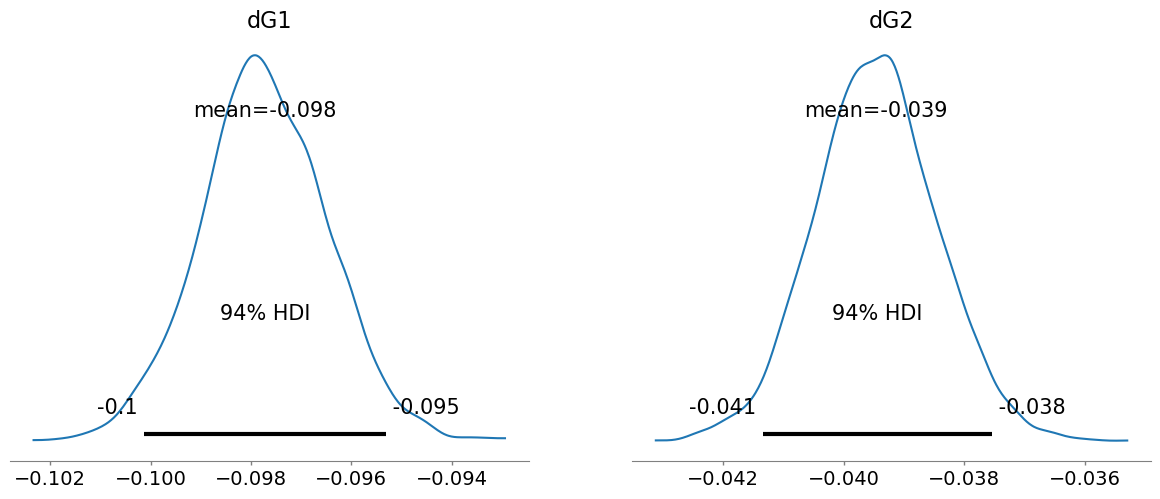

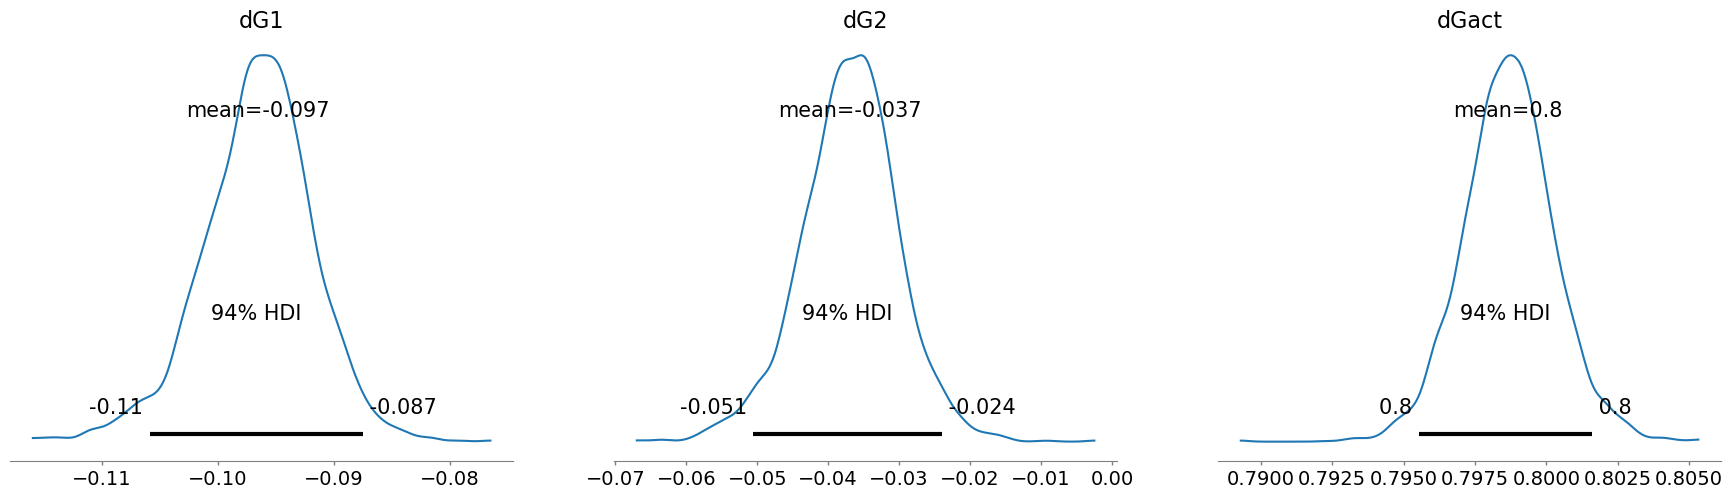

In [8]:
print("\n--- Fit 1: Thetas Summary ---")
print(az.summary(trace_thetas, var_names=['dG1', 'dG2']))

print("\n--- Fit 2: Rate Summary ---")
print(az.summary(trace_rate, var_names=['dG1', 'dG2', 'dGact']))

az.plot_posterior(trace_thetas, var_names=['dG1', 'dG2'])
plt.show()

az.plot_posterior(trace_rate, var_names=['dG1', 'dG2', 'dGact'])
plt.show()

In [6]:


# 5. Plotter
def plot_mixed_model_vs_exp(dGact_val, dG1_val, dG2_val):
    log_t1 = log_P - dG1_val / kT
    log_t2 = log_C - dG2_val / kT
    log_den = np.logaddexp(0, np.logaddexp(log_t1, log_t2))
    
    th_CO_mod = np.exp(log_t1 - log_den)
    th_OH_mod = np.exp(log_t2 - log_den)
    log_rate_mod = (log_prefactor - dGact_val / kT) + log_C + log_t1 - log_den
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    
    axes[0].scatter(th_CO_mod, theta_CO_exp, c='b')
    axes[0].set_title(r"Linear $\theta_{CO}$")
    
    axes[1].scatter(th_OH_mod, theta_OH_exp, c='g')
    axes[1].set_title(r"Linear $\theta_{OH}$")
    
    axes[2].scatter(log_rate_mod, log_rate_exp, c='r')
    axes[2].set_title("log(Rate) - TST")
    
    for ax in axes:
        lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
        ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
        ax.set_xlabel("Model")
        ax.set_ylabel("Experimental")
        
    plt.tight_layout()
    plt.show()

# plot_mixed_model_vs_exp(0.8, -0.05, -0.05)